# Rental Bike Demand Prediction

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Load Data

In [2]:
data_path = r"Data/Raw_Data.csv"
df = pd.read_csv(data_path, encoding = "unicode_escape")
df.shape

(8760, 14)

In [3]:
df.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [4]:
df.tail()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
8755,30/11/2018,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Autumn,No Holiday,Yes
8756,30/11/2018,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8757,30/11/2018,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8758,30/11/2018,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes
8759,30/11/2018,584,23,1.9,43,1.3,1909,-9.3,0.0,0.0,0.0,Autumn,No Holiday,Yes


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   str    
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   str    
 12  Holiday                    8760 non-null   str    
 13  Functioning Day            8760 non-null   str    
dtypes: 

In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,8760,365,01/12/2017,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rented Bike Count,8760.0,NaN,NaN,NaN,704.602055,644.997468,0.0,191.0,504.5,1065.25,3556.0
Hour,8760.0,NaN,NaN,NaN,11.5,6.922582,0.0,5.75,11.5,17.25,23.0
Temperature(°C),8760.0,NaN,NaN,NaN,12.882922,11.944825,-17.8,3.5,13.7,22.5,39.4
Humidity(%),8760.0,NaN,NaN,NaN,58.226256,20.362413,0.0,42.0,57.0,74.0,98.0
Wind speed (m/s),8760.0,NaN,NaN,NaN,1.724909,1.0363,0.0,0.9,1.5,2.3,7.4
Visibility (10m),8760.0,NaN,NaN,NaN,1436.825799,608.298712,27.0,940.0,1698.0,2000.0,2000.0
Dew point temperature(°C),8760.0,NaN,NaN,NaN,4.073813,13.060369,-30.6,-4.7,5.1,14.8,27.2
Solar Radiation (MJ/m2),8760.0,NaN,NaN,NaN,0.569111,0.868746,0.0,0.0,0.01,0.93,3.52
Rainfall(mm),8760.0,NaN,NaN,NaN,0.148687,1.128193,0.0,0.0,0.0,0.0,35.0


Check NULL Value

In [7]:
df.isnull().sum()

Date                         0
Rented Bike Count            0
Hour                         0
Temperature(°C)              0
Humidity(%)                  0
Wind speed (m/s)             0
Visibility (10m)             0
Dew point temperature(°C)    0
Solar Radiation (MJ/m2)      0
Rainfall(mm)                 0
Snowfall (cm)                0
Seasons                      0
Holiday                      0
Functioning Day              0
dtype: int64

In [8]:
"""
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df["Weekday"] = df["Date"].dt.day_name()
df["Day"] = df["Date"].dt.day
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year

df.drop("Date", axis=1, inplace=True)
"""

'\ndf["Date"] = pd.to_datetime(df["Date"], errors="coerce")\n\ndf["Weekday"] = df["Date"].dt.day_name()\ndf["Day"] = df["Date"].dt.day\ndf["Month"] = df["Date"].dt.month\ndf["Year"] = df["Date"].dt.year\n\ndf.drop("Date", axis=1, inplace=True)\n'

In [9]:
"""Improved Code"""

df["Date"] = pd.to_datetime(
    df["Date"],
    format="%d/%m/%Y",
    errors="coerce"
)

df["Weekday"] = df["Date"].dt.day_name()
df["Day"] = df["Date"].dt.day
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year



In [10]:
df[["Date", "Day", "Month", "Year"]].head()

,Date,Day,Month,Year
0,2017-12-01,1,12,2017
1,2017-12-01,1,12,2017
2,2017-12-01,1,12,2017
3,2017-12-01,1,12,2017
4,2017-12-01,1,12,2017


In [11]:
df.drop("Date", axis=1, inplace=True)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Rented Bike Count          8760 non-null   int64  
 1   Hour                       8760 non-null   int64  
 2   Temperature(°C)            8760 non-null   float64
 3   Humidity(%)                8760 non-null   int64  
 4   Wind speed (m/s)           8760 non-null   float64
 5   Visibility (10m)           8760 non-null   int64  
 6   Dew point temperature(°C)  8760 non-null   float64
 7   Solar Radiation (MJ/m2)    8760 non-null   float64
 8   Rainfall(mm)               8760 non-null   float64
 9   Snowfall (cm)              8760 non-null   float64
 10  Seasons                    8760 non-null   str    
 11  Holiday                    8760 non-null   str    
 12  Functioning Day            8760 non-null   str    
 13  Weekday                    8760 non-null   str    
 14  Day

In [13]:
df.head()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Weekday,Day,Month,Year
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,Friday,1,12,2017
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,Friday,1,12,2017
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,Friday,1,12,2017
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,Friday,1,12,2017
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,Friday,1,12,2017


## EDA

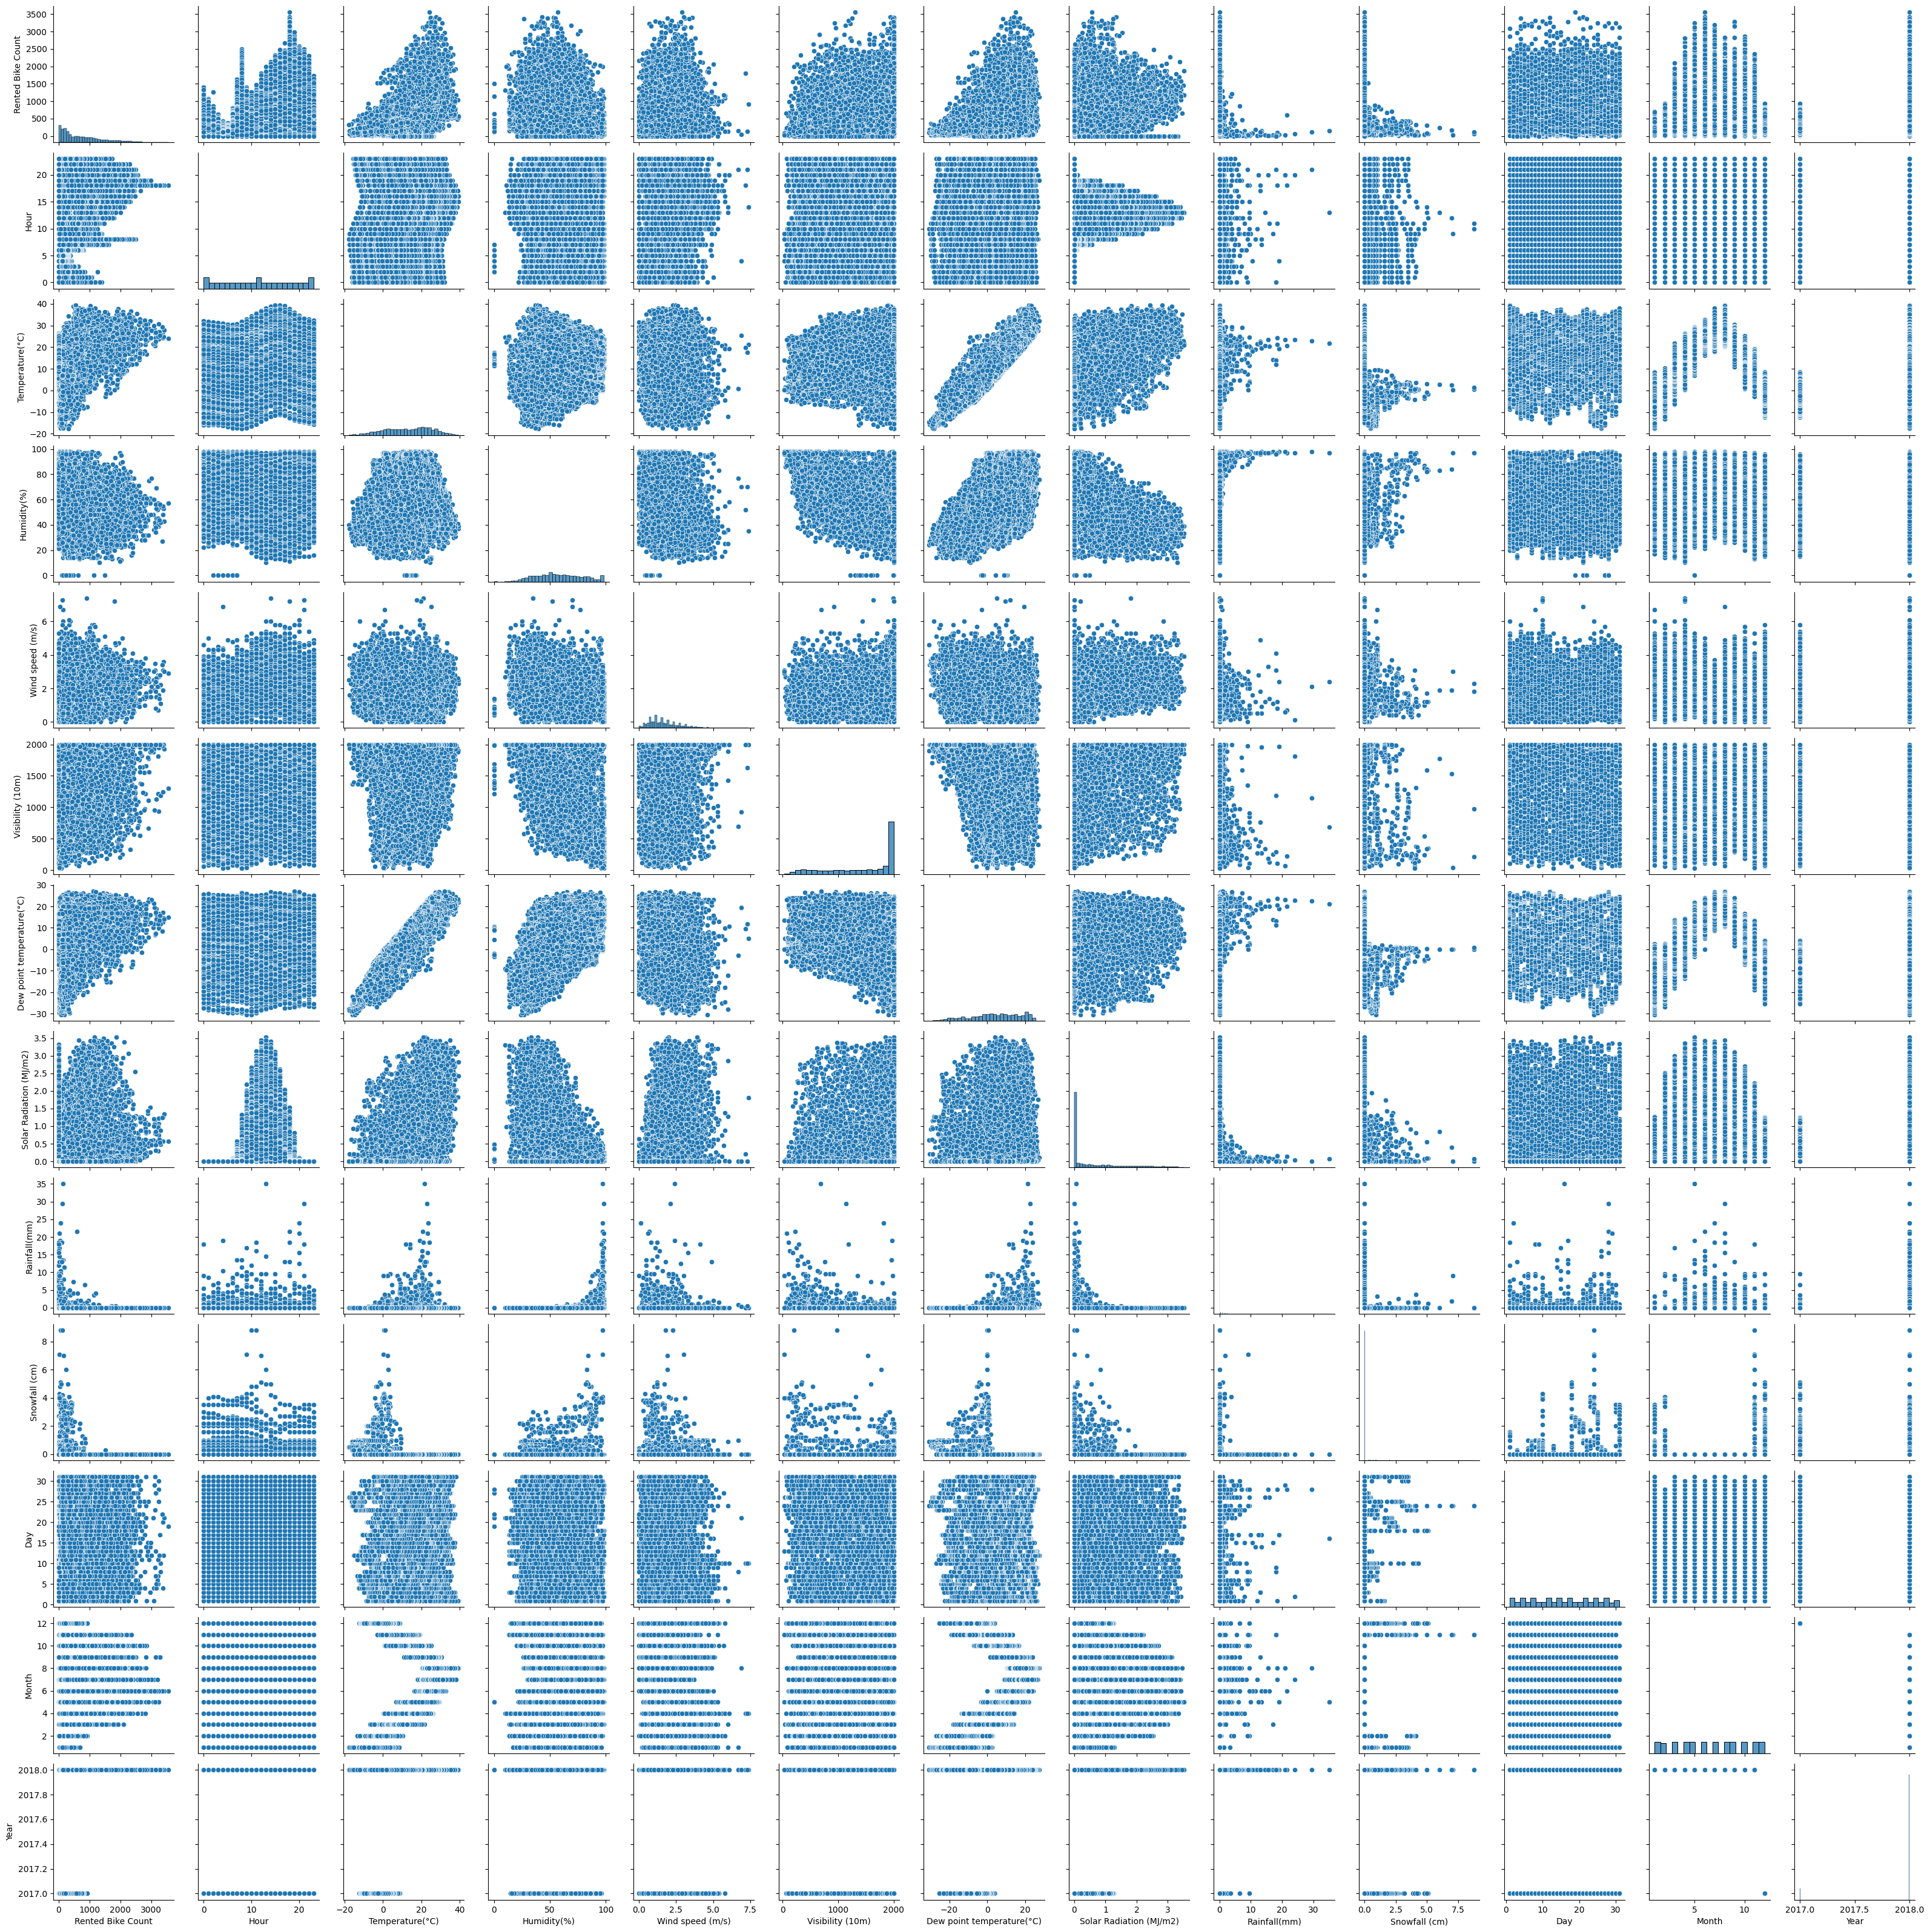

In [14]:
sns.pairplot(df)

<Axes: xlabel='Month', ylabel='Rented Bike Count'>

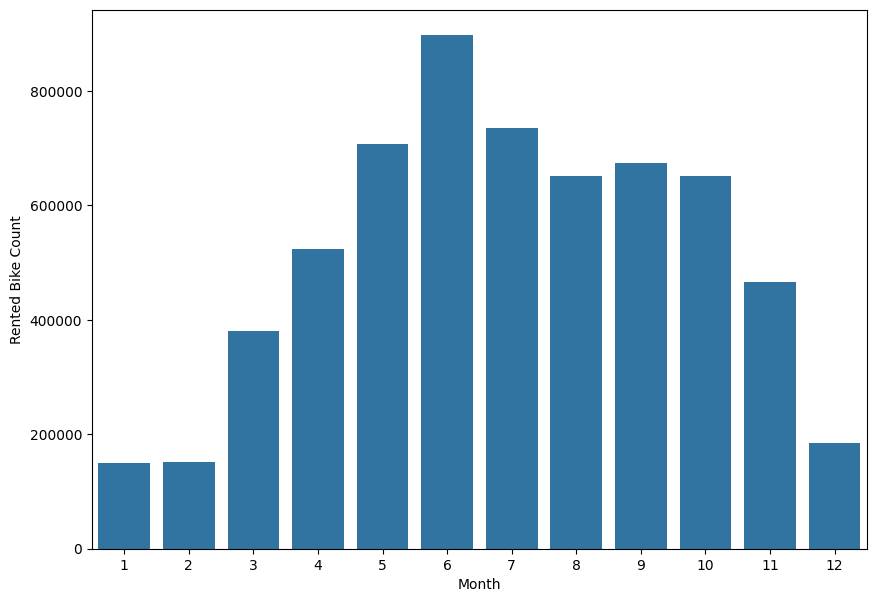

In [15]:
plt.figure(figsize=(10,7))
Month = df.groupby("Month").sum().reset_index()
sns.barplot(x="Month", y="Rented Bike Count", data=Month)

<Axes: xlabel='Month', ylabel='Rented Bike Count'>

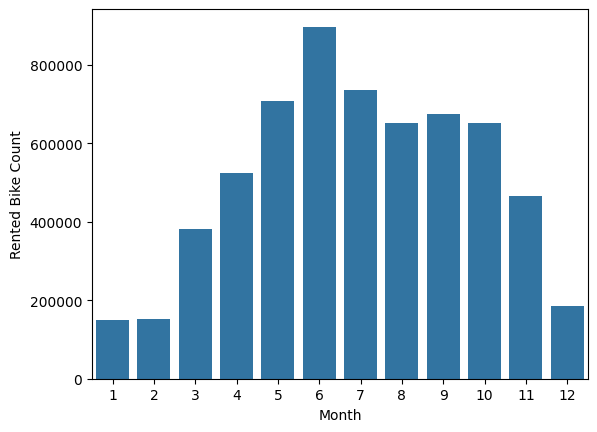

In [16]:
"""Improved Code"""

Month = df.groupby("Month")["Rented Bike Count"].sum().reset_index()

sns.barplot(
    x="Month",
    y="Rented Bike Count",
    data=Month
)

<Axes: xlabel='Day', ylabel='Rented Bike Count'>

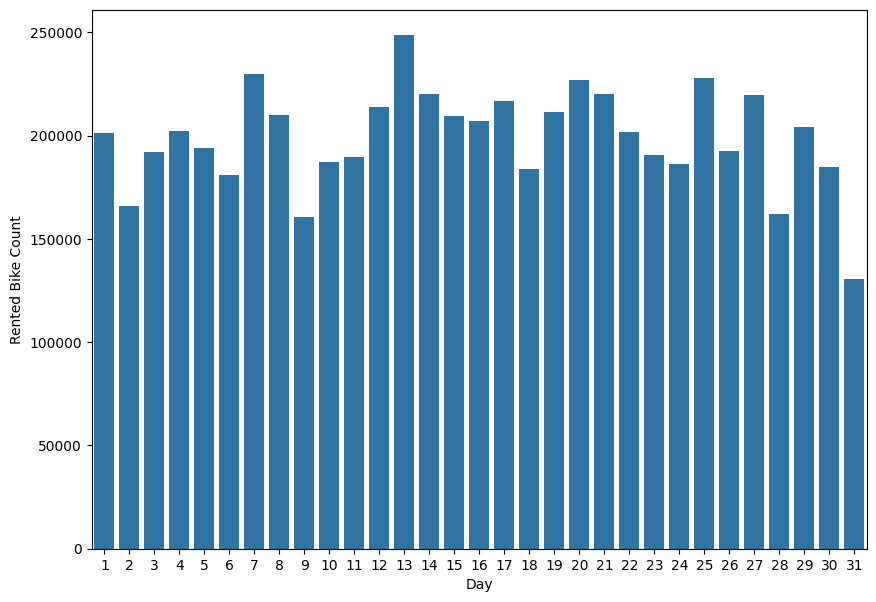

In [17]:
plt.figure(figsize=(10,7))
Month = df.groupby("Day").sum().reset_index()
sns.barplot(x="Day", y="Rented Bike Count", data=Month)

<Axes: xlabel='Day', ylabel='Rented Bike Count'>

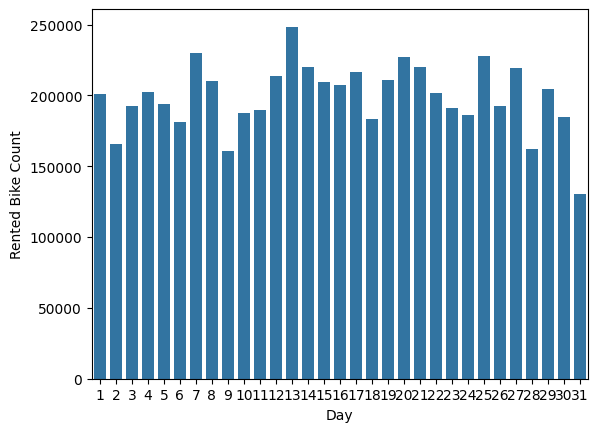

In [18]:
"""Improved Code"""

Day = df.groupby("Day")["Rented Bike Count"].sum().reset_index()

sns.barplot(
    x="Day",
    y="Rented Bike Count",
    data=Day
)


<Axes: xlabel='Hour', ylabel='Rented Bike Count'>

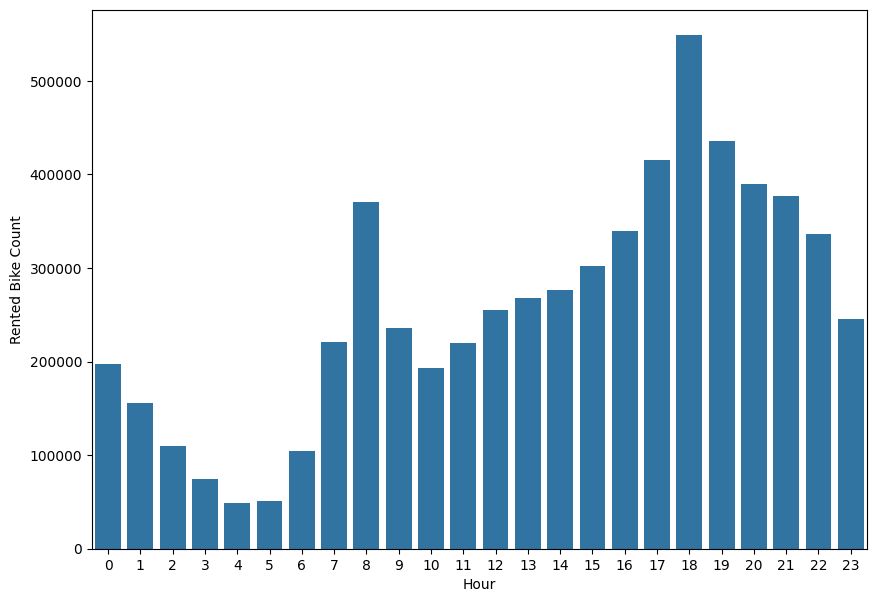

In [19]:
plt.figure(figsize=(10,7))
Hour= df.groupby("Hour").sum().reset_index()
sns.barplot(x="Hour", y="Rented Bike Count", data=Hour)

<Axes: xlabel='Holiday', ylabel='Rented Bike Count'>

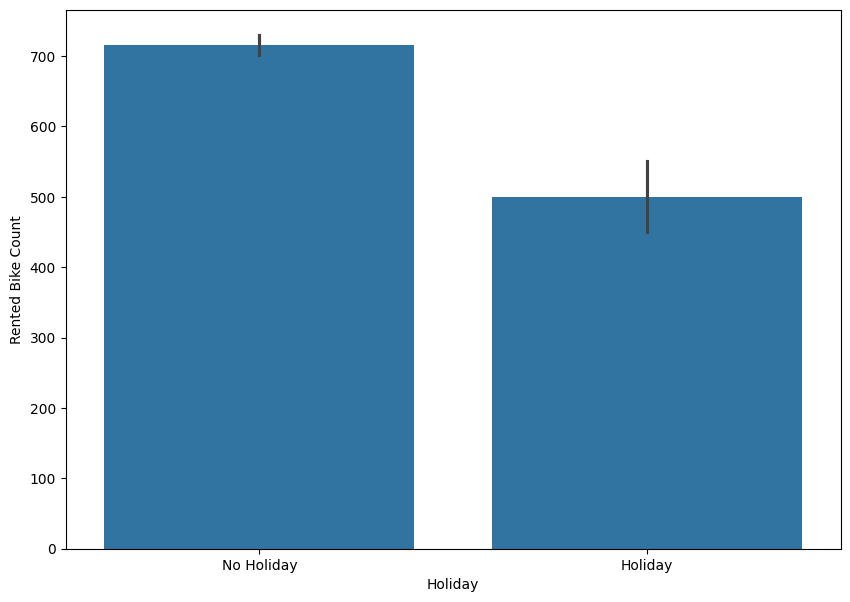

In [20]:
plt.figure(figsize=(10,7))
sns.barplot(x="Holiday", y="Rented Bike Count", data=df)

<Axes: xlabel='Seasons', ylabel='Rented Bike Count'>

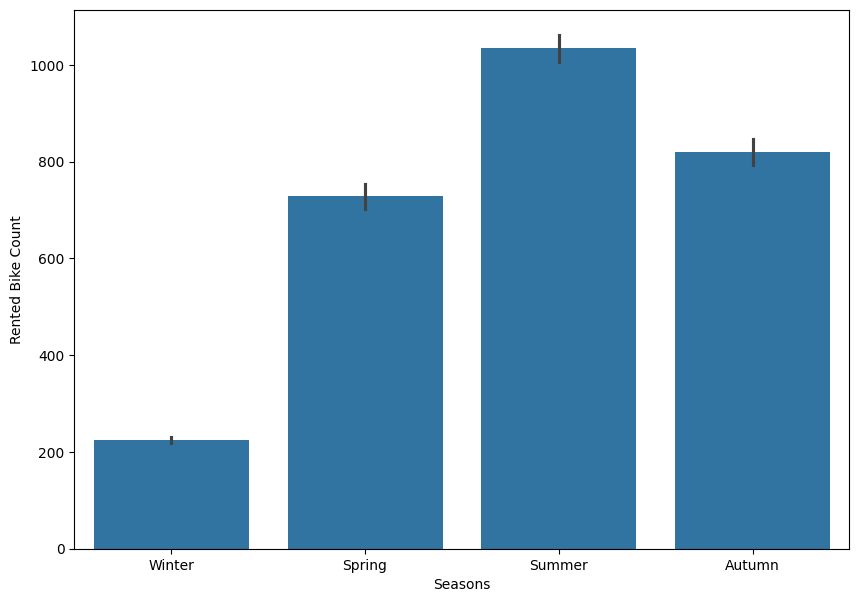

In [21]:
plt.figure(figsize=(10,7))
sns.barplot(x="Seasons", y="Rented Bike Count", data=df)

<Axes: xlabel='Rainfall(mm)', ylabel='Rented Bike Count'>

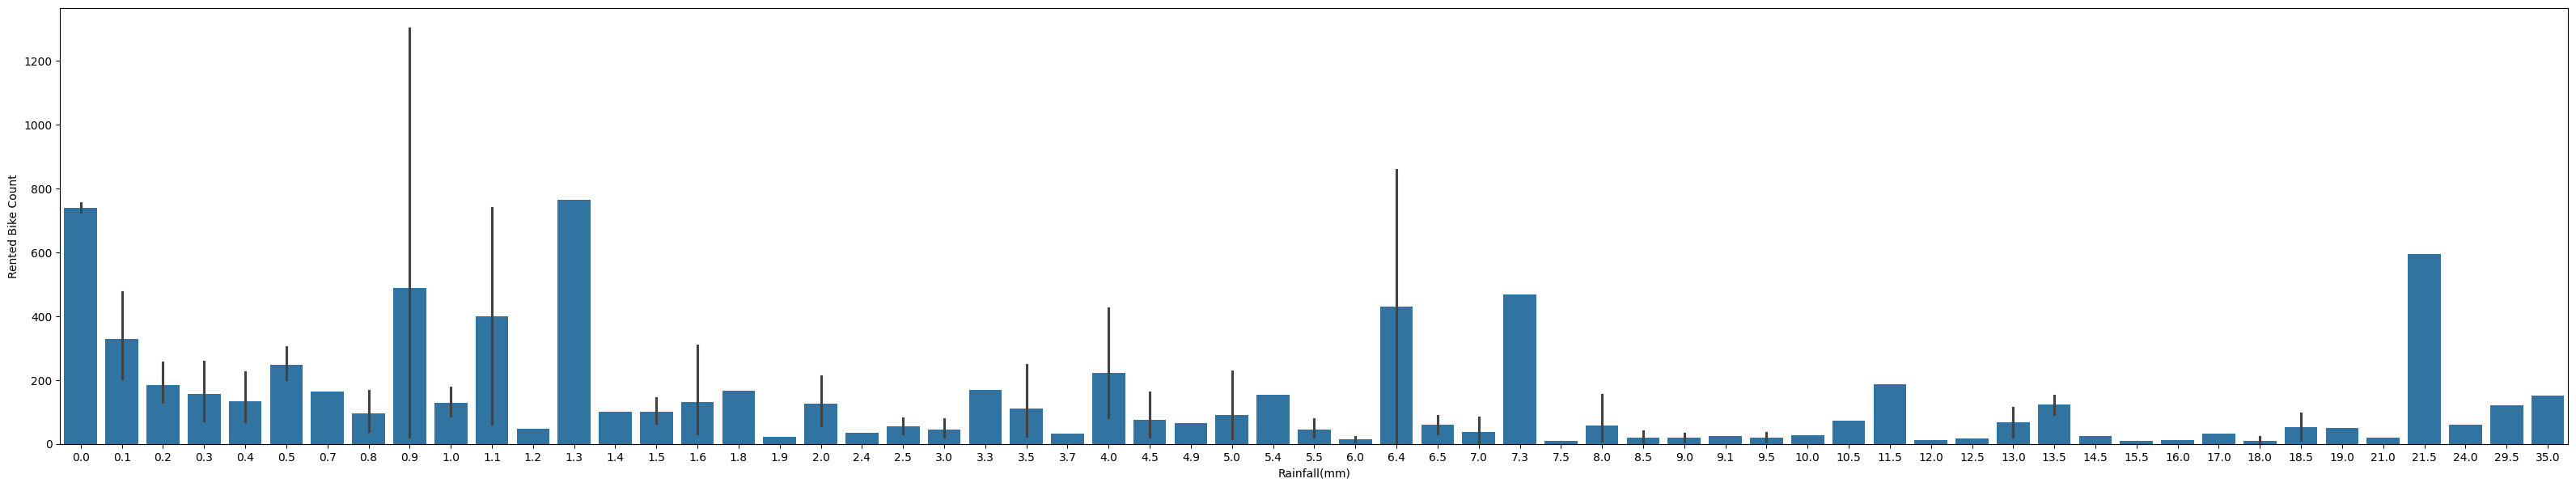

In [22]:
plt.figure(figsize=(40,7))
sns.barplot(x="Rainfall(mm)", y="Rented Bike Count", data=df)

<Axes: xlabel='Snowfall (cm)', ylabel='Rented Bike Count'>

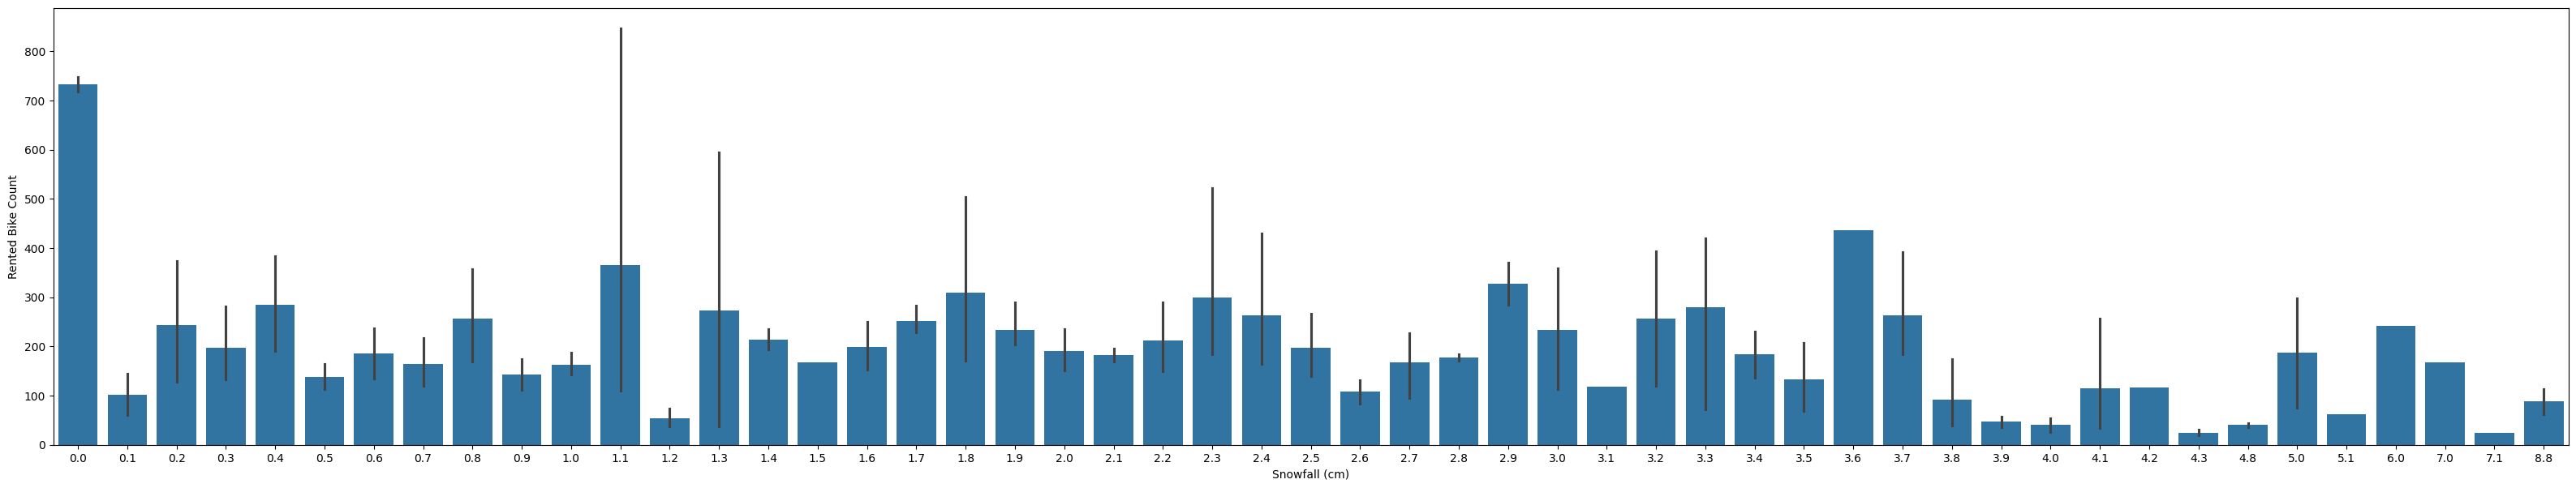

In [23]:
plt.figure(figsize=(40,7))
sns.barplot(x="Snowfall (cm)", y="Rented Bike Count", data=df)

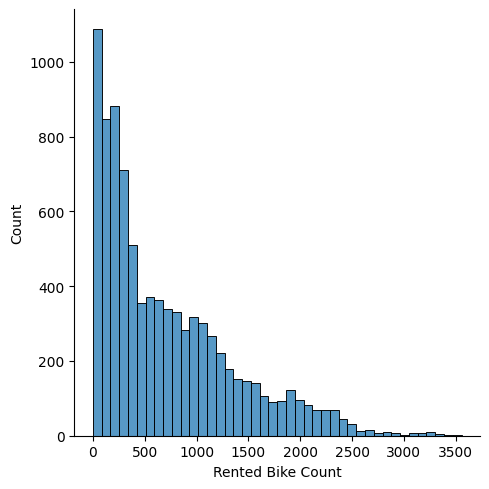

In [24]:
sns.displot(df["Rented Bike Count"])

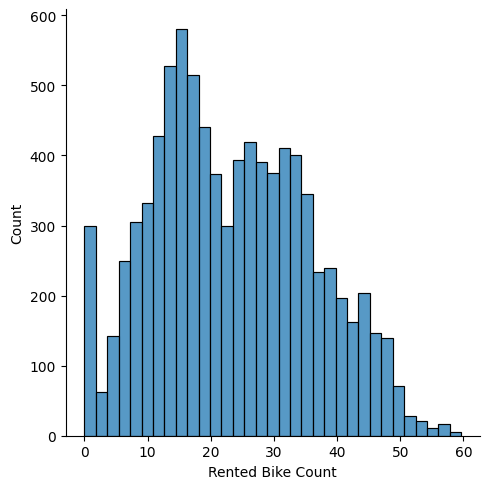

In [25]:
sns.displot(np.sqrt(df["Rented Bike Count"]))

## Skewed Data

In [26]:
df.skew(numeric_only=True).sort_values(ascending=True)

Year                         -2.978262
Visibility (10m)             -0.701786
Dew point temperature(°C)    -0.367298
Temperature(°C)              -0.198326
Month                        -0.010458
Hour                          0.000000
Day                           0.007522
Humidity(%)                   0.059579
Wind speed (m/s)              0.890955
Rented Bike Count             1.153428
Solar Radiation (MJ/m2)       1.504040
Snowfall (cm)                 8.440801
Rainfall(mm)                 14.533232
dtype: float64

## Remove Multicollinearity

<Axes: >

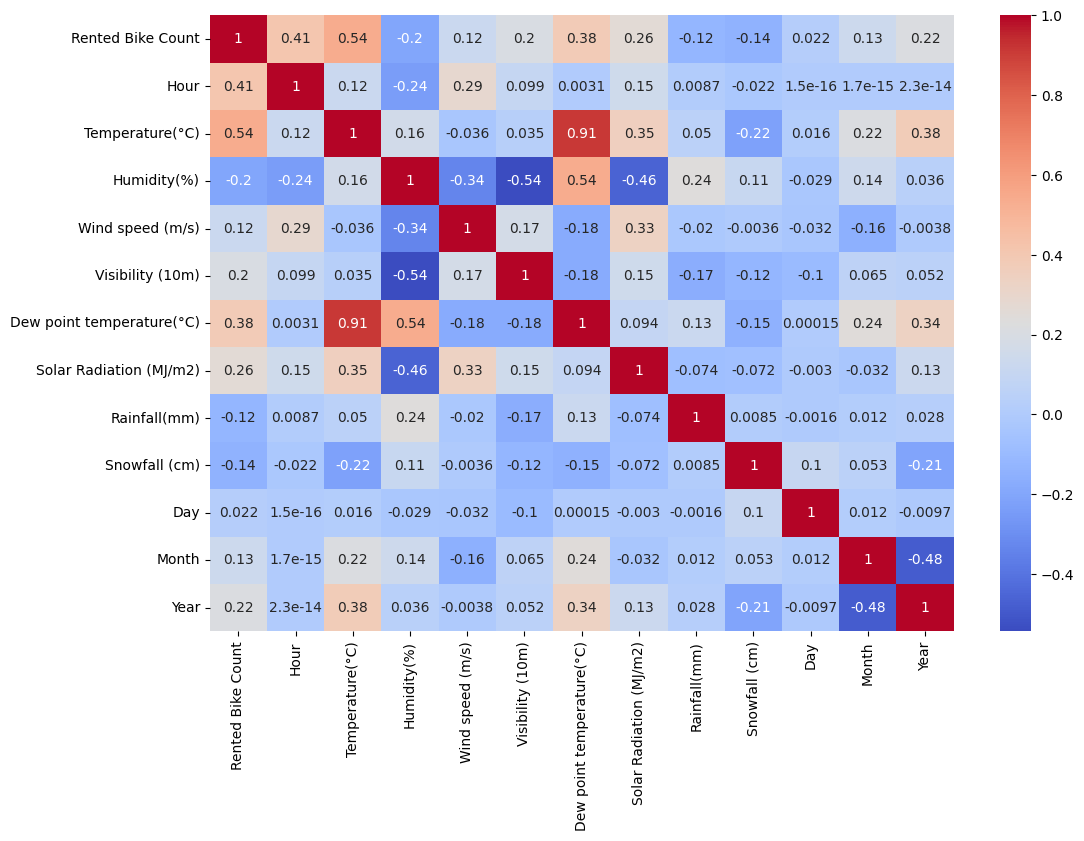

In [27]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")

## drop = Dew Point Temperature

In [28]:
def get_vif(df):
    vif = pd.DataFrame()
    vif["variables"] = df.columns
    vif["VIF"] = [
        variance_inflation_factor(df.values, i)
        for i in range(df.shape[1])
    ]

    return vif

In [29]:
vif_df = df.select_dtypes(include="number")

vif_df = vif_df.drop(
    columns=["Day", "Month", "Year", "Rented Bike Count"],
    errors="ignore"
)
get_vif(vif_df)

,variables,VIF
0,Hour,1.183686
1,Temperature(°C),87.112576
2,Humidity(%),20.362259
3,Wind speed (m/s),1.276095
4,Visibility (10m),1.567300
5,Dew point temperature(°C),115.691025
6,Solar Radiation (MJ/m2),2.021193
7,Rainfall(mm),1.084427
8,Snowfall (cm),1.095396


In [30]:
not_for_vif = ["Day", "Month", "Year", "Rented Bike Count", "Dew point temperature(°C)"]

get_vif(
    df[[i for i in df.describe().columns if i not in not_for_vif]]
)

,variables,VIF
0,Hour,1.181468
1,Temperature(°C),1.623991
2,Humidity(%),2.534083
3,Wind speed (m/s),1.274067
4,Visibility (10m),1.556883
5,Solar Radiation (MJ/m2),1.924897
6,Rainfall(mm),1.070513
7,Snowfall (cm),1.090421


In [31]:
df.drop("Dew point temperature(°C)", axis=1, inplace=True)

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Rented Bike Count        8760 non-null   int64  
 1   Hour                     8760 non-null   int64  
 2   Temperature(°C)          8760 non-null   float64
 3   Humidity(%)              8760 non-null   int64  
 4   Wind speed (m/s)         8760 non-null   float64
 5   Visibility (10m)         8760 non-null   int64  
 6   Solar Radiation (MJ/m2)  8760 non-null   float64
 7   Rainfall(mm)             8760 non-null   float64
 8   Snowfall (cm)            8760 non-null   float64
 9   Seasons                  8760 non-null   str    
 10  Holiday                  8760 non-null   str    
 11  Functioning Day          8760 non-null   str    
 12  Weekday                  8760 non-null   str    
 13  Day                      8760 non-null   int32  
 14  Month                    8760 non-n

In [33]:
cat_features = ["Seasons","Holiday","Functioning Day","Weekday"]

In [34]:
df["Holiday"].value_counts()

Holiday
No Holiday    8328
Holiday        432
Name: count, dtype: int64

In [35]:
df["Functioning Day"].value_counts()

Functioning Day
Yes    8465
No      295
Name: count, dtype: int64

In [36]:
df["Seasons"].value_counts()

Seasons
Spring    2208
Summer    2208
Autumn    2184
Winter    2160
Name: count, dtype: int64

In [37]:
df["Weekday"].value_counts()

Weekday
Friday       1272
Saturday     1248
Sunday       1248
Monday       1248
Tuesday      1248
Wednesday    1248
Thursday     1248
Name: count, dtype: int64

In [38]:
df["Holiday"] = df["Holiday"].map({"No Holiday": 0, "Holiday": 1})
df["Functioning Day"] = df["Functioning Day"].map({"No": 0, "Yes": 1})

In [39]:
df_season = pd.get_dummies(df["Seasons"], drop_first = True, dtype=int)
df_weekday = pd.get_dummies(df["Weekday"], drop_first = True, dtype=int)

In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Rented Bike Count        8760 non-null   int64  
 1   Hour                     8760 non-null   int64  
 2   Temperature(°C)          8760 non-null   float64
 3   Humidity(%)              8760 non-null   int64  
 4   Wind speed (m/s)         8760 non-null   float64
 5   Visibility (10m)         8760 non-null   int64  
 6   Solar Radiation (MJ/m2)  8760 non-null   float64
 7   Rainfall(mm)             8760 non-null   float64
 8   Snowfall (cm)            8760 non-null   float64
 9   Seasons                  8760 non-null   str    
 10  Holiday                  8760 non-null   int64  
 11  Functioning Day          8760 non-null   int64  
 12  Weekday                  8760 non-null   str    
 13  Day                      8760 non-null   int32  
 14  Month                    8760 non-n

In [41]:
df = pd.concat([df, df_season, df_weekday], axis=1)

In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Rented Bike Count        8760 non-null   int64  
 1   Hour                     8760 non-null   int64  
 2   Temperature(°C)          8760 non-null   float64
 3   Humidity(%)              8760 non-null   int64  
 4   Wind speed (m/s)         8760 non-null   float64
 5   Visibility (10m)         8760 non-null   int64  
 6   Solar Radiation (MJ/m2)  8760 non-null   float64
 7   Rainfall(mm)             8760 non-null   float64
 8   Snowfall (cm)            8760 non-null   float64
 9   Seasons                  8760 non-null   str    
 10  Holiday                  8760 non-null   int64  
 11  Functioning Day          8760 non-null   int64  
 12  Weekday                  8760 non-null   str    
 13  Day                      8760 non-null   int32  
 14  Month                    8760 non-n

In [43]:
df.drop(["Seasons", "Weekday"], axis=1, inplace=True)

In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Rented Bike Count        8760 non-null   int64  
 1   Hour                     8760 non-null   int64  
 2   Temperature(°C)          8760 non-null   float64
 3   Humidity(%)              8760 non-null   int64  
 4   Wind speed (m/s)         8760 non-null   float64
 5   Visibility (10m)         8760 non-null   int64  
 6   Solar Radiation (MJ/m2)  8760 non-null   float64
 7   Rainfall(mm)             8760 non-null   float64
 8   Snowfall (cm)            8760 non-null   float64
 9   Holiday                  8760 non-null   int64  
 10  Functioning Day          8760 non-null   int64  
 11  Day                      8760 non-null   int32  
 12  Month                    8760 non-null   int32  
 13  Year                     8760 non-null   int32  
 14  Spring                   8760 non-n

In [45]:
df.head()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Holiday,...,Year,Spring,Summer,Winter,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
0,254,0,-5.2,37,2.2,2000,0.0,0.0,0.0,0,...,2017,0,0,1,0,0,0,0,0,0
1,204,1,-5.5,38,0.8,2000,0.0,0.0,0.0,0,...,2017,0,0,1,0,0,0,0,0,0
2,173,2,-6.0,39,1.0,2000,0.0,0.0,0.0,0,...,2017,0,0,1,0,0,0,0,0,0
3,107,3,-6.2,40,0.9,2000,0.0,0.0,0.0,0,...,2017,0,0,1,0,0,0,0,0,0
4,78,4,-6.0,36,2.3,2000,0.0,0.0,0.0,0,...,2017,0,0,1,0,0,0,0,0,0


In [46]:
df.columns

Index(['Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Solar Radiation (MJ/m2)',
       'Rainfall(mm)', 'Snowfall (cm)', 'Holiday', 'Functioning Day', 'Day',
       'Month', 'Year', 'Spring', 'Summer', 'Winter', 'Monday', 'Saturday',
       'Sunday', 'Thursday', 'Tuesday', 'Wednesday'],
      dtype='str')

In [47]:
df.shape

(8760, 23)

## Split Data for Training & Testing

In [48]:
X = df.drop("Rented Bike Count", axis=1)
y = df["Rented Bike Count"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=2023)

print("Shape of X_train: ", X_train.shape)
print("Shape of y_train: ", y_train.shape)
print("Shape of X_test: ", X_test.shape)
print("Shape of y_test: ", y_test.shape)

Shape of X_train:  (7008, 22)
Shape of y_train:  (7008,)
Shape of X_test:  (1752, 22)
Shape of y_test:  (1752,)


## Scaling

In [49]:
sc = StandardScaler()
sc.fit(X_train)

X_train = sc.transform(X_train)
X_test = sc.transform(X_test)

In [50]:
X_train[:2]

array([[ 1.51118219,  0.05556521, -2.10940521,  0.46658045,  0.92262892,
        -0.65681529, -0.12916836, -0.17535463, -0.22754885,  0.18254726,
        -0.41966071, -0.72590612,  0.30459857,  1.74132735, -0.58152447,
        -0.57866842, -0.40630934, -0.40916536, -0.4075004 ,  2.46842407,
        -0.40081071, -0.41367015],
       [ 0.93371229,  1.00382241, -0.25185689,  1.82005277,  0.92262892,
         0.82386154, -0.12916836, -0.17535463, -0.22754885,  0.18254726,
        -0.41966071, -0.14689974,  0.30459857, -0.57427456,  1.71961809,
        -0.57866842, -0.40630934, -0.40916536, -0.4075004 , -0.40511677,
         2.49494334, -0.41367015]])

In [51]:
sc.mean_

array([1.15323916e+01, 1.28319920e+01, 5.81522546e+01, 1.71738014e+00,
       1.44041795e+03, 5.67796804e-01, 1.52539954e-01, 7.52283105e-02,
       4.92294521e-02, 9.67751142e-01, 1.56847888e+01, 6.50742009e+00,
       2.01791510e+03, 2.48002283e-01, 2.52711187e-01, 2.50856164e-01,
       1.41695205e-01, 1.43407534e-01, 1.42408676e-01, 1.40981735e-01,
       1.38413242e-01, 1.46118721e-01])

In [52]:
sc.scale_

array([6.92676802e+00, 1.20220548e+01, 2.04570722e+01, 1.03437653e+00,
       6.06508248e+02, 8.64469525e-01, 1.18093896e+00, 4.29006703e-01,
       2.16346743e-01, 1.76660323e-01, 8.78039972e+00, 3.45419336e+00,
       2.78737249e-01, 4.31853159e-01, 4.34566730e-01, 4.33505881e-01,
       3.48737257e-01, 3.50487965e-01, 3.49468804e-01, 3.48002709e-01,
       3.45333196e-01, 3.53225198e-01])

## Training ML Model

## Linear Regression Model

In [53]:
from sklearn.linear_model import LinearRegression

In [54]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](22,)","[ 190.07, 321.35,-176.11,..., -7.57, -6.93, -0.84]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,707.7
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,22
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(22)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](22,)","[138.23,126.33,113.44,..., 34.66, 29.36, 9.27]"


In [55]:
y_pred = lr.predict(X_test)

In [56]:
y_pred

array([  -3.42150244, 1022.33291293, 1474.26387368, ..., 1524.82148315,
        547.90926416,  739.64325466], shape=(1752,))

## Model Evaluation

In [57]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [58]:
MSE = mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)
MAE = mean_absolute_error(y_test, y_pred)
R2 = r2_score(y_test, y_pred)

print(f"MSE :{MSE}")
print(f"RMSE :{RMSE}")
print(f"MAE :{MAE}")
print(f"R2 :{R2}")

MSE :186569.98193192578
RMSE :431.9374745630735
MAE :330.21078355249136
R2 :0.5429221393038915


In [59]:
def get_metrics(y_true, y_pred, model_name):
    MSE = mean_squared_error(y_test, y_pred)
    RMSE = np.sqrt(MSE)
    MAE = mean_absolute_error(y_test, y_pred)
    R2 = r2_score(y_test, y_pred)

    print(f"{model_name} : ['MSE': {round(MSE,3)}, 'RMSE':{round(RMSE,3)}, 'MSE': {round(MAE,3)}, 'R2': {round(R2,3)}]")

In [60]:
get_metrics(y_test, y_pred, "LinearRegression")

LinearRegression : ['MSE': 186569.982, 'RMSE':431.937, 'MSE': 330.211, 'R2': 0.543]


## Train Multiple Model

In [61]:
!pip install XGBoost

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: C:\Users\Lenovo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [72]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [73]:
dtr = DecisionTreeRegressor().fit(X_train, y_train)
y_pred_dtr = dtr.predict(X_test)
rfr = RandomForestRegressor().fit(X_train, y_train)
y_pred_rfr = rfr.predict(X_test)
xgbr = XGBRegressor().fit(X_train, y_train)
y_pred_xgbr = xgbr.predict(X_test)

In [74]:
get_metrics(y_test, y_pred_dtr, "DecisionTreeRegressor")
get_metrics(y_test, y_pred_rfr, "RandomForestRegressor")
get_metrics(y_test, y_pred_xgbr, "XGBRegressor")

DecisionTreeRegressor : ['MSE': 58397.408, 'RMSE':241.656, 'MSE': 131.83, 'R2': 0.857]
RandomForestRegressor : ['MSE': 30104.298, 'RMSE':173.506, 'MSE': 98.406, 'R2': 0.926]
XGBRegressor : ['MSE': 25361.389, 'RMSE':159.253, 'MSE': 97.863, 'R2': 0.938]


## Visualise Model Prediction

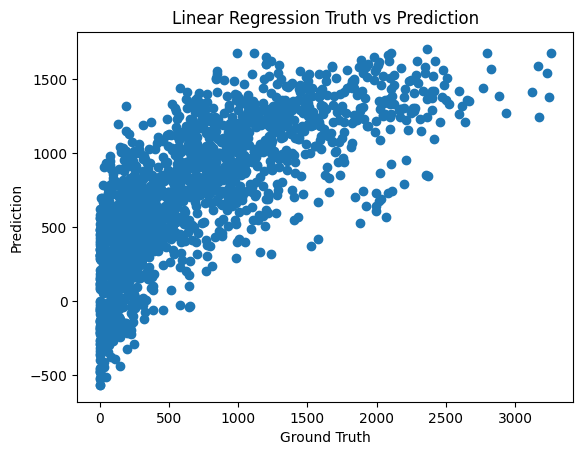

In [68]:
plt.scatter(y_test, y_pred)
plt.title("Linear Regression Truth vs Prediction")
plt.xlabel("Ground Truth")
plt.ylabel("Prediction")
plt.show()

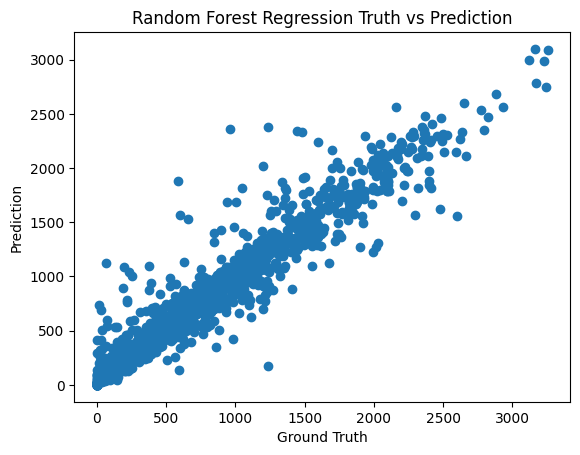

In [75]:
plt.scatter(y_test, y_pred_rfr)
plt.title("Random Forest Regression Truth vs Prediction")
plt.xlabel("Ground Truth")
plt.ylabel("Prediction")
plt.show()

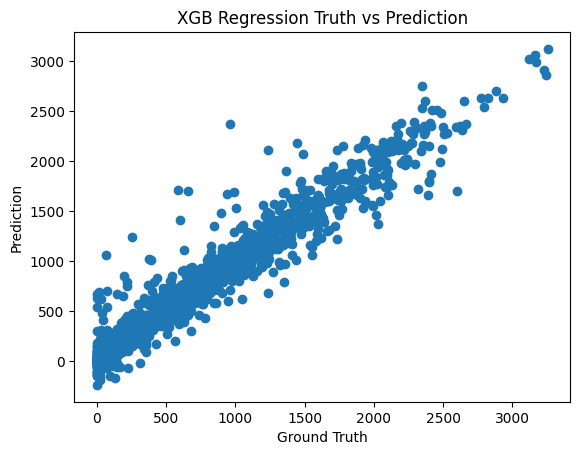

In [76]:
plt.scatter(y_test, y_pred_xgbr)
plt.title("XGB Regression Truth vs Prediction")
plt.xlabel("Ground Truth")
plt.ylabel("Prediction")
plt.show()

## Hyperparameter tuning for Random Forest Regressor

In [77]:
from sklearn.model_selection import RandomizedSearchCV

# Number of trees in random forest
n_estimators = [int(x) for x in np.linspace(start=200, stop=2000, num=10)]

# Number of features to consider at every split
max_features = ['sqrt', 'log2']

# Maximum number of levels allowed in each decision tree
max_depth = [int(x) for x in np.linspace(10, 120, num=12)]

# Minimum number of samples required to split a node
min_samples_split = [2, 5, 10]

# Minimum number of samples required at each leaf node
min_samples_leaf = [1, 2, 4]

# Method of selecting samples for training each tree
bootstrap = [True, False]

# Create the random grid
random_grid = {
    'n_estimators': n_estimators,
    'max_features': max_features,
    'max_depth': max_depth,
    'min_samples_split': min_samples_split,
    'min_samples_leaf': min_samples_leaf,
    'bootstrap': bootstrap
}

In [78]:
import time

start_time = time.time()

rf = RandomForestRegressor()

# Random search of parameters, using 3 fold cross validation,
# search across 100 different combinations, and use all available cores
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=random_grid,
    n_iter=100,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Fit the randomized search model
rf_random.fit(X_train, y_train)

y_pred_rf_random = rf_random.predict(X_test)

print("Time taken to training using randomize search : ", time.time() - start_time)

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Time taken to training using randomize search :  317.1013729572296


In [ ]:
get_metrics(
    y_test,
    y_pred_rf_random,
    "RandomForestRegressor Fine Tuning"
)

In [ ]:
rf_random.best_params_

In [ ]:
rf_tuned = RandomForestRegressor(
    n_estimators=400,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    max_depth=120,
    bootstrap=False
)

rf_tuned.fit(X_train, y_train)

y_pred_rf_tuned = rf_tuned.predict(X_test)

get_metrics(
    y_test,
    y_pred_rf_tuned,
    "RandomForestRegressor With Best Parameters"
)

## Hyperparameter Tuning for XGBoost Regressor

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import time

start_time = time.time()

params = {
    'max_depth': [3, 5, 6, 10, 15, 20],
    'learning_rate': [0.01, 0.1, 0.2, 0.3],
    'subsample': np.arange(0.5, 1.0, 0.1),
    'colsample_bytree': np.arange(0.4, 1.0, 0.1),
    'colsample_bylevel': np.arange(0.4, 1.0, 0.1),
    'n_estimators': [100, 500, 1000]
}

xgbr = XGBRegressor(seed=20)

rscv = RandomizedSearchCV(
    estimator=xgbr,
    param_distributions=params,
    scoring='neg_mean_squared_error',
    n_iter=25,
    cv=5,
    verbose=1
)

rscv.fit(X_train, y_train)

y_pred_xgb_random = rscv.predict(X_test)

get_metrics(
    y_test,
    y_pred_xgb_random,
    "XGBRegressor With Best Parameters"
)

print("Time taken to training using randomize search : ", time.time() - start_time)

print("Best parameters:", rscv.best_params_)

In [ ]:
xdbr = XGBRegressor(subsample=0.6,
                   n_estimates=1000,
                   max_depth=6,
                   learning_rate=0.1,
                   colsample_bytree=0.7,
                   seed=20)

xgbr.fit(X_train,y_train)

y_pred_tuned = xgbr.predict(X_test)

get_metrics(y_test, y_pred_tuned, "XGBRegressor With Best Parameters")

Changing Value

In [ ]:
xdbr = XGBRegressor(subsample=0.6,
                   n_estimates=1000,
                   max_depth=6,
                   learning_rate=0.08,
                   colsample_bytree=0.7,
                   seed=20)

xgbr.fit(X_train,y_train)

y_pred_tuned = xgbr.predict(X_test)

get_metrics(y_test, y_pred_tuned, "XGBRegressor With Best Parameters")

## Save ML Best Model

In [79]:
import pickle
import os

dir = r"D:\new_folder\Bike Demand Prediction\Model"
model_file_name = "xgboost_regressor_r2_0_938_v1.pkl"

model_file_path = os.path.join(dir, model_file_name)

with open(model_file_path, "wb") as f:
    pickle.dump(xgbr, f)

In [ ]:
X_test[0,:]

In [ ]:
X_test[1,:]

In [ ]:
y_test

## Dump Scaling Parameters

In [ ]:
sc_dump_path = r"D:\new_folder\Bike Demand Prediction\Model\sc.pkl"

pickle.dump(sc, open(sc_dump_path, "wb"))